# Verificación de locutor de texto dependiente

Proyecto de Biometría de la Voz. El objetivo es construir un sistema que,
dado un audio de una persona diciendo un PIN, sea capaz de:

1. **Identificar al locutor** — ¿quién está hablando? (Red 1)
2. **Verificar la frase** — ¿ha dicho el PIN correcto? (Red 2)

Este notebook es el *orquestador*: no contiene la lógica interna, solo
llama en orden a las funciones de los módulos `src/data.py`,
`src/model.py` y `src/train.py`, y muestra los resultados.

## Base de datos

Usamos `PIN_16kHz`: 24 locutores que pronuncian PINs de 4 dígitos.
Tras la exploración (fase previa) sabemos que hay **2658 audios válidos**,
**40 clases de PIN** distintas, y descartamos 222 audios marcados como
defectuosos `(def)`, que se reservan para pruebas de robustez.

## 1. Preparación del entorno y carga de datos

Importamos los módulos del proyecto. La línea `sys.path.append("src")`
le dice a Python que busque también en la carpeta `src/`, que es donde
están nuestros módulos.

A continuación cargamos el dataset. Procesar los 2658 audios (leer cada
WAV y extraer sus MFCC) tarda un par de minutos, así que usamos una
**caché**: la primera vez se procesa todo y se guarda en un fichero
`cache_dataset.npz`; las siguientes veces se carga directamente de ahí,
en segundos.

procedemos a entrenar

In [5]:
import sys, os
sys.path.append("src")

import numpy as np
import data, model, train

CACHE = "cache_dataset.npz"

if os.path.exists(CACHE):
    # La caché ya existe: cargamos de disco (rápido)
    d = np.load(CACHE, allow_pickle=True)
    X, y_loc, y_pin = d["X"], d["y_loc"], d["y_pin"]
    mapas = d["mapas"].item()
    print("Dataset cargado de la caché:", X.shape)
else:
    # Primera vez: procesamos los audios y guardamos la caché
    registros = data.construir_indice()
    X, y_loc, y_pin, mapas = data.construir_dataset(registros)
    np.savez(CACHE, X=X, y_loc=y_loc, y_pin=y_pin, mapas=mapas)
    print("Dataset procesado y guardado en caché:", X.shape)

Dataset cargado de la caché: (2658, 120, 63, 1)


## 2. Red 1 — Identificación del locutor

La primera red responde a la pregunta *"¿quién está hablando?"*. Es una
**CNN** (red convolucional) con **24 salidas**, una por cada locutor de
la base de datos.

### División de los datos

Antes de entrenar, dividimos los 2658 audios en tres grupos:

- **Train (70%)**: la red aprende con ellos.
- **Validación (15%)**: vigilamos el entrenamiento sin que la red aprenda
  de ellos; sirve para detectar sobreajuste.
- **Test (15%)**: no se tocan hasta el final; dan la medida honesta del
  rendimiento.

La división es *estratificada*: cada locutor aparece en los tres grupos
en la misma proporción.

In [6]:
# Dividimos los datos para la Red 1 (estratificado por LOCUTOR)
Xtr, Xv, Xte, ytr, yv, yte = data.dividir_datos(X, y_loc)

Splits -> train: 1860  |  val: 399  |  test: 399


### Creación y entrenamiento del modelo

Creamos la CNN con `model.construir_modelo`. Le pasamos:
- `"cnn"`: el tipo de arquitectura (la otra opción es `"cnn_lstm"`).
- `input_shape`: la forma de cada audio (nº de características × tiempo).
- `n_clases=24`: una salida por locutor.

Después la entrenamos. Cada *época* es una pasada completa por los datos
de train. El entrenamiento se detiene solo (EarlyStopping) cuando la red
deja de mejorar en validación.

In [7]:
# Creamos la CNN de 24 clases (una por locutor)
red1 = model.construir_modelo("cnn", input_shape=X.shape[1:], n_clases=24)

# La entrenamos. Guardará la mejor versión en resultados/red1_locutor.keras
hist1 = train.entrenar(red1, Xtr, ytr, Xv, yv,
                       ruta_modelo="resultados/red1_locutor.keras")


Entrenando 'CNN'...
  Train: 1860  |  Val: 399
  Batch: 32  |  Épocas máx: 60

Epoch 1/60


2026-05-17 17:27:18.236233: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 56246400 exceeds 10% of free system memory.
2026-05-17 17:27:18.287855: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 56246400 exceeds 10% of free system memory.


59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.1118 - loss: 3.0715 - val_accuracy: 0.0451 - val_loss: 3.2046
Epoch 2/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2193 - loss: 2.4631 - val_accuracy: 0.0451 - val_loss: 3.7077
Epoch 3/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2786 - loss: 2.1694 - val_accuracy: 0.0927 - val_loss: 3.8219
Epoch 4/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3529 - loss: 1.9269 - val_accuracy: 0.1028 - val_loss: 3.2301
Epoch 5/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4069 - loss: 1.7397 - val_accuracy: 0.1980 - val_loss: 2.6062
Epoch 6/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4745 - loss: 1.5633 - val_accuracy: 0.1980 - val_loss: 2.8370
Epoch 7/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5040 - loss: 1.4870 - val_accuracy: 0.2857 - val_loss: 1.9310
Epoch 8/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5321 - loss: 1.3815 - val_accuracy: 0.2080 - val_loss: 2.6952
Ep

### Evaluación de la Red 1

Entrenada la red, la evaluamos sobre el conjunto de **test** — los audios
que la red no ha visto nunca. El resultado en test es la medida honesta
de su rendimiento.

Generamos dos figuras:

- **Curvas de entrenamiento**: accuracy y pérdida a lo largo de las
  épocas, comparando train y validación. Si las curvas de train y
  validación se separan mucho, hay sobreajuste.
- **Matriz de confusión**: tabla que muestra, para cada locutor real,
  qué locutor predijo la red. La diagonal son los aciertos; lo de fuera,
  los errores.

In [8]:
# Lista de nombres de locutor, ordenada igual que las etiquetas
nombres_loc = sorted(mapas["locutor"].keys())

# Evaluamos sobre el conjunto de test
res1 = train.evaluar(red1, Xte, yte, nombres_clases=nombres_loc)


=== Evaluación en TEST ===
  Pérdida  : 0.5583
  Accuracy : 82.46%

              precision    recall  f1-score   support

         093       1.00      1.00      1.00        14
         147       1.00      0.44      0.62        18
         291       1.00      0.27      0.43        11
         379       0.87      0.72      0.79        18
         527       0.80      0.94      0.86        17
         544       0.55      0.94      0.69        18
         626       0.94      1.00      0.97        16
         639       1.00      0.53      0.69        17
         774       0.58      1.00      0.73        18
         785       1.00      0.71      0.83        17
         920       0.74      1.00      0.85        17
         a77       1.00      0.47      0.64        17
         b48       1.00      0.89      0.94        18
         b73       1.00      0.94      0.97        18
         c09       0.49      1.00      0.65        17
         c70       0.79      0.69      0.73        16
         d42

#### Figuras

Curvas guardadas en resultados/red1_curvas.png


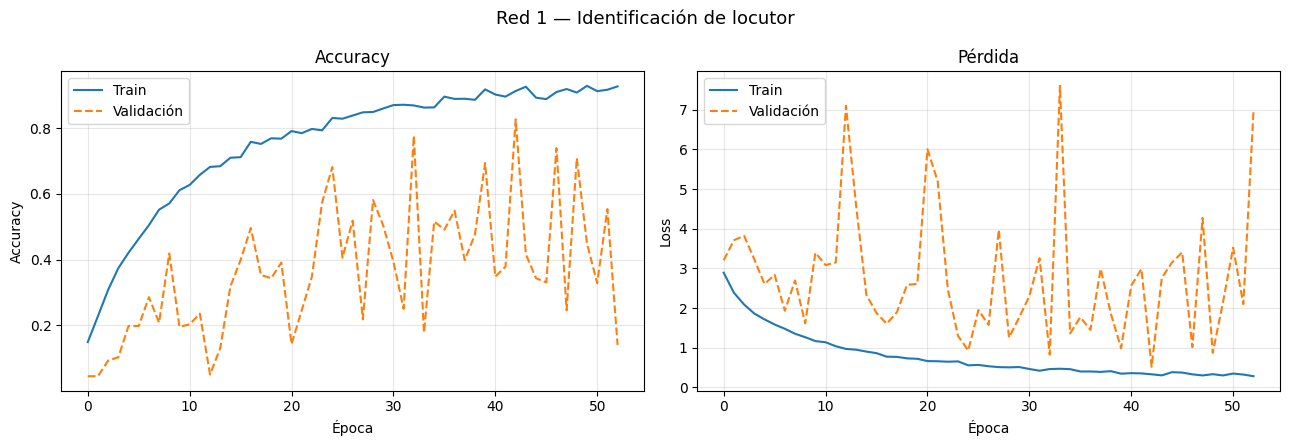

Matriz guardada en resultados/red1_matriz.png


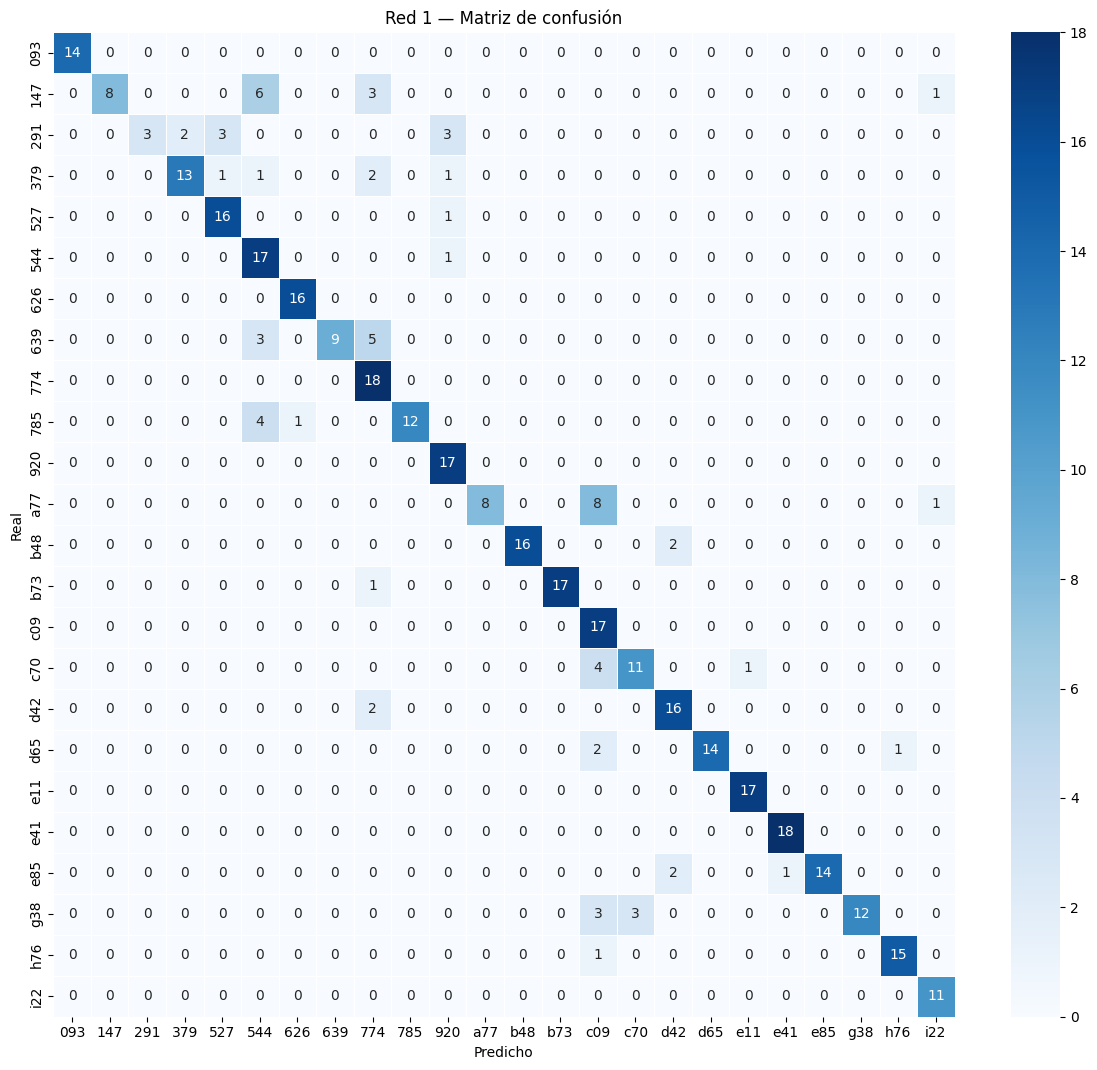

In [9]:
# Curvas de entrenamiento
train.graficar_entrenamiento(
    hist1,
    titulo="Red 1 — Identificación de locutor",
    guardar="resultados/red1_curvas.png",
)

# Matriz de confusión
train.graficar_matriz_confusion(
    res1, nombres_loc,
    titulo="Red 1 — Matriz de confusión",
    guardar="resultados/red1_matriz.png",
)